# 08 · Comparar 4 checkpoints de una corrida de `cats_vp.yaml`

Compara los **snapshots de una misma corrida** (`config/cats_vp.yaml`) para ver cómo evoluciona el
modelo a lo largo del entrenamiento, y grafica las curvas del experimento:

1. **Descubrimiento y metadata** de los checkpoints (los `…_stepNNNNN.pt` + el final).
2. **Curva de pérdida** del experimento: la serie **densa** de entrenamiento (`event: "step"`) más las
   series **dispersas** de validación, con marcas en los pasos de los 4 checkpoints.
3. **raw vs EMA**: `val_raw` (pesos vivos) contra `val_ema` (sombra EMA) del log, y su diferencia.
4. **Generación comparada**: los 4 checkpoints generan con el **mismo sampler y la misma semilla**
   (mismo $x_T$), así la única variable es *cuánto entrenó* el modelo.

### Cómo se conectan las piezas (lo que aprendimos del notebook 07)

- `generate_from_checkpoint(ckpt, sampler_name=…, n_samples=…, n_steps=…, seed=…, device="cuda")`
  hace todo: reconstruye la SDE (`meta["sde_name"]`, `meta["data_dim"]`), rearma la red con
  `make_model(meta["model"]["name"], **meta["model"]["kwargs"])`, y —si la receta trae
  `score_parametrization: "epsilon"`— la envuelve sola en `EpsilonScoreWrapper`. No hay que
  reconstruir nada a mano para generar.
- Los checkpoints publican la **sombra EMA**; el hermano `…_raw.pt` (solo el final) tiene los pesos
  crudos del último paso de Adam.

### Consideraciones de descubrimiento (importantes)

- Los snapshots se llaman `<stem>_step{paso:05d}.pt`, y **al lado** de cada uno vive su sidecar
  `<stem>_step{paso:05d}.resume.pt`. Un glob ingenuo `cats_vp_step*.pt` **también matchea el
  sidecar**, que no es un checkpoint de pesos → se excluye explícitamente.
- El **paso** de cada checkpoint se lee de `len(meta["history"])` (la serie densa tiene un valor por
  paso), que es más confiable que parsear el nombre y también funciona para el checkpoint final.
- Las rutas salen de `config/cats_vp.yaml` (`out.checkpoint` / `out.train_log`). Se pueden
  sobreescribir con las variables de entorno `CATS_VP_CKPT` y `CATS_VP_LOG` (útil para correr el
  mismo notebook en otra máquina sin editar celdas).

In [9]:
# --- Setup: bootstrap de sys.path + imports + helpers ---
import sys
import pathlib
import os
import re
import json

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.training import load_checkpoint
from diffusion.samplers import generate_from_checkpoint, available_samplers

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def denorm(t):
    """(B,3,H,W) en [-1,1] -> (B,H,W,3) numpy en [0,1]."""
    x = (t.detach() * 0.5 + 0.5).clamp(0.0, 1.0)
    return x.permute(0, 2, 3, 1).cpu().numpy()


print("paquete en:", _root)
print("torch:", torch.__version__, "| device:", DEVICE)
print("samplers:", available_samplers())

# --- Presupuesto de computo: NFE, no pasos --------------------------------------
# Cada sampler gasta un numero DISTINTO de evaluaciones del score por paso (contado
# sobre el codigo de diffusion/samplers):
#   euler   -> 1                (_reverse_drift)
#   pf_ode  -> 1                (_pfode_drift)
#   heun    -> 2                (drift en t y en el estado predicho a t+dt)
#   pc      -> 1 + n_corrector  (predictor + cada correccion de Langevin)
# Darles el mismo `n_steps` NO es darles el mismo computo: heun y pc gastan el doble.
# Con la U-Net dominando el costo, el NFE es basicamente el tiempo de pared, asi que
# comparar samplers a `n_steps` igualado le regala 2x a dos de los cuatro.
import time

N_CORRECTOR = 1
NFE_POR_PASO = {"euler": 1, "pf_ode": 1, "heun": 2, "pc": 1 + N_CORRECTOR}


def pasos_para(nom_sampler, nfe):
    """Pasos de integracion que gastan `nfe` evaluaciones de score con este sampler."""
    if nom_sampler not in NFE_POR_PASO:
        raise KeyError(f"NFE/paso desconocido para '{nom_sampler}'; agregalo a NFE_POR_PASO")
    return max(1, nfe // NFE_POR_PASO[nom_sampler])


def kwargs_para(nom_sampler):
    """Kwargs propios del sampler. Solo `pc` los tiene, y `n_corrector` va explicito
    porque el conteo de NFE depende de el: si cambia el default, el conteo miente."""
    return {"n_corrector": N_CORRECTOR} if nom_sampler == "pc" else {}


print("NFE por paso:", NFE_POR_PASO)

paquete en: /home/abravo/estocastico/diffusion-models
torch: 2.12.0+cu130 | device: cuda
samplers: ['euler', 'heun', 'pc', 'pf_ode']


## 1. Descubrir los checkpoints y leer su metadata

Resolvemos las rutas desde el YAML, descubrimos los snapshots + el final (excluyendo sidecars y, por
defecto, el hermano `_raw.pt`) y los ordenamos por paso.

In [10]:
# --- Rutas: del YAML, con override por variable de entorno ---
CONFIG_PATH = _root / "config" / "cats_vp-overfitting.yaml"

ckpt_target, log_target = None, None
if CONFIG_PATH.exists():
    import yaml
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        _cfg = yaml.safe_load(f)
    ckpt_target = pathlib.Path(_cfg["out"]["checkpoint"])
    if _cfg["out"].get("train_log"):
        log_target = pathlib.Path(_cfg["out"]["train_log"])

# Override manual (o por env) para correr en otra máquina sin editar el notebook.
if os.environ.get("CATS_VP_CKPT"):
    ckpt_target = pathlib.Path(os.environ["CATS_VP_CKPT"])
if os.environ.get("CATS_VP_LOG"):
    log_target = pathlib.Path(os.environ["CATS_VP_LOG"])

if ckpt_target is None:
    raise FileNotFoundError(
        f"No pude resolver la ruta del checkpoint: falta {CONFIG_PATH} y no está CATS_VP_CKPT."
    )

CKPT_DIR, CKPT_STEM = ckpt_target.parent, ckpt_target.stem
print("checkpoint final (YAML):", ckpt_target)
print("log de entrenamiento   :", log_target)
print("carpeta de checkpoints :", CKPT_DIR, "| existe:", CKPT_DIR.is_dir())

checkpoint final (YAML): /mnt/data/abravo/diffusion-models/phase_2-overfitting/cats_vp.pt
log de entrenamiento   : /mnt/data/abravo/diffusion-models/phase_2-overfitting/cats_vp_train_log.jsonl
carpeta de checkpoints : /mnt/data/abravo/diffusion-models/phase_2-overfitting | existe: True


In [11]:
# --- Descubrimiento de checkpoints de la corrida ---
N_CKPT = 4           # cuántos comparar (los más recientes por paso)
INCLUDE_RAW = False  # incluir el hermano de pesos crudos …_raw.pt del checkpoint final


def discover_checkpoints(ckpt_dir, stem, *, include_raw=False):
    """Devuelve [(paso, ruta, meta)] de la corrida, ordenado por paso.

    Excluye los sidecars de resume (…_stepNNNNN.resume.pt), que matchean el glob pero NO son
    checkpoints de pesos. El paso sale de len(meta['history']) (un valor por paso), que también
    funciona para el checkpoint final (sin sufijo _stepNNNNN en el nombre).
    """
    ckpt_dir = pathlib.Path(ckpt_dir)
    if not ckpt_dir.is_dir():
        raise FileNotFoundError(f"No existe la carpeta de checkpoints: {ckpt_dir}")

    encontrados = []
    for p in sorted(ckpt_dir.glob(f"{stem}*.pt")):
        if p.name.endswith(".resume.pt"):
            continue                                  # sidecar de reanudación, no pesos
        es_raw = p.stem.endswith("_raw")
        if es_raw and not include_raw:
            continue
        try:
            _sd, meta = load_checkpoint(p, map_location="cpu")
        except (KeyError, RuntimeError) as exc:
            print(f"  (salteado {p.name}: no parece un checkpoint válido — {exc})")
            continue
        hist = meta.get("history") or []
        m = re.search(r"_step(\d+)", p.stem)
        paso = len(hist) if hist else (int(m.group(1)) if m else -1)
        encontrados.append((paso, p, meta))

    encontrados.sort(key=lambda t: t[0])
    return encontrados


todos = discover_checkpoints(CKPT_DIR, CKPT_STEM, include_raw=INCLUDE_RAW)
if not todos:
    raise FileNotFoundError(
        f"No encontré checkpoints '{CKPT_STEM}*.pt' en {CKPT_DIR}. "
        "¿Está la corrida ahí, o hay que apuntar CATS_VP_CKPT a otra ruta?"
    )
ckpts = todos[-N_CKPT:]   # los N más avanzados

print(f"Checkpoints encontrados: {len(todos)} | comparando {len(ckpts)}\n")
for paso, p, _m in ckpts:
    print(f"  paso {paso:>7,} -> {p.name}")

Checkpoints encontrados: 5 | comparando 4

  paso  75,000 -> cats_vp_step75000.pt
  paso  90,000 -> cats_vp_step90000.pt
  paso 105,000 -> cats_vp_step105000.pt
  paso 120,000 -> cats_vp.pt


In [12]:
# --- Tabla de metadata por checkpoint ---
filas = []
for paso, p, meta in ckpts:
    hist = meta.get("history") or []
    vh = meta.get("val_history") or []
    ultimo_val = vh[-1] if vh else {}
    recipe = meta.get("model") or {}
    filas.append({
        "checkpoint": p.name,
        "paso": paso,
        "train (densa, últ.)": hist[-1] if hist else None,
        "val raw": ultimo_val.get("raw"),
        "val EMA": ultimo_val.get("ema"),
        "train fijo": ultimo_val.get("train"),
        "pesos": "EMA" if meta.get("ema") else "crudos",
    })

hdr = ["checkpoint", "paso", "train (densa, últ.)", "val raw", "val EMA", "train fijo", "pesos"]
anchos = [max(len(h), *(len(f"{f[h]}") if not isinstance(f[h], float) else 9 for f in filas)) for h in hdr]
print(" | ".join(h.ljust(w) for h, w in zip(hdr, anchos)))
print("-+-".join("-" * w for w in anchos))
for f in filas:
    celdas = []
    for h, w in zip(hdr, anchos):
        v = f[h]
        s = f"{v:.6f}" if isinstance(v, float) else ("—" if v is None else f"{v:,}" if h == "paso" else str(v))
        celdas.append(s.ljust(w))
    print(" | ".join(celdas))

meta_ref = ckpts[-1][2]
print(f"\nSDE: {meta_ref.get('sde_name')} | data_dim={meta_ref.get('data_dim')}")
recipe = meta_ref.get("model") or {}
print(f"Red: {recipe.get('name')} | parametrización: {recipe.get('score_parametrization', 'score directo')}")
print(f"     kwargs={recipe.get('kwargs')}")

# El gap de generalización: el par comparable es 'train (examen fijo)' vs 'val (pesos vivos)'
# — NO la curva densa per-step contra la de validación (son estimadores distintos).
for f in filas:
    if f["val raw"] is not None and f["train fijo"] is not None:
        print(f"  paso {f['paso']:>7,}: gap val-train(fijo) = {f['val raw'] - f['train fijo']:+.6f}")

checkpoint            | paso   | train (densa, últ.) | val raw   | val EMA   | train fijo | pesos
----------------------+--------+---------------------+-----------+-----------+------------+------
cats_vp_step75000.pt  | 75,000 | 0.019257            | 0.027340  | 0.026869  | 0.026104   | EMA  
cats_vp_step90000.pt  | 90,000 | 0.021068            | 0.028077  | 0.027681  | 0.025267   | EMA  
cats_vp_step105000.pt | 105,000 | 0.021361            | 0.029043  | 0.028683  | 0.024620   | EMA  
cats_vp.pt            | 120,000 | 0.020218            | 0.030039  | 0.029797  | 0.023943   | EMA  

SDE: vp | data_dim=(3, 64, 64)
Red: unet | parametrización: epsilon
     kwargs={'in_channels': 3, 'image_size': 64, 'base_channels': 128, 'channel_mults': [1, 2, 2, 2], 'num_res_blocks': 2, 'embed_dim': 256, 'time_embed_dim': 512, 'attn_resolutions': [16, 8], 'groups': 32, 'time_scale': 1000.0}
  paso  75,000: gap val-train(fijo) = +0.001236
  paso  90,000: gap val-train(fijo) = +0.002810
  paso 105,000: 

## 2. Curva de pérdida del experimento (desde el `.jsonl`)

El log tiene dos tipos de registro relevantes:

- `{"event": "step", "step", "loss"}` — la serie **densa** de entrenamiento (media móvil por cadencia
  de log).
- `{"event": "val", "step", "val_raw", "val_ema", "train_fijo", "device"}` — la serie **dispersa** de
  validación, con los tres estimadores.

Las líneas verticales marcan los pasos de los 4 checkpoints comparados.

In [13]:
# --- Parseo del log .jsonl ---
def load_train_log(path):
    """Lee el .jsonl y separa los registros por tipo de evento."""
    path = pathlib.Path(path)
    if not path.exists():
        return None
    recs = []
    with open(path, "r", encoding="utf-8") as fh:
        for linea in fh:
            linea = linea.strip()
            if not linea:
                continue
            try:
                recs.append(json.loads(linea))
            except json.JSONDecodeError:
                continue    # línea truncada (corrida cortada): se ignora
    return recs


recs = load_train_log(log_target) if log_target else None

if recs is None:
    print(f"No encontré el log en {log_target}. Salteo las curvas del .jsonl y uso "
          "el meta de los checkpoints más abajo.")
    steps_ev, vals_ev = [], []
else:
    steps_ev = [r for r in recs if r.get("event") == "step" and r.get("loss") is not None]
    vals_ev = [r for r in recs if r.get("event") == "val"]
    inicio = next((r for r in recs if r.get("event") == "start"), {})
    print(f"log: {len(recs)} registros | {len(steps_ev)} 'step' | {len(vals_ev)} 'val'")
    if inicio:
        print(f"  start: sde={inicio.get('sde')} device={inicio.get('device')} "
              f"num_steps={inicio.get('num_steps')} amp={inicio.get('amp')}")
    devs = {r.get("device") for r in vals_ev if r.get("device")}
    if len(devs) > 1:
        print(f"  OJO: la serie de validación se midió en más de un device {devs}: el examen fijo "
              "es específico del device, así que el salto puede ser del cambio de máquina.")

log: 243 registros | 120 'step' | 120 'val'
  start: sde=vp device=cuda num_steps=120000 amp=True


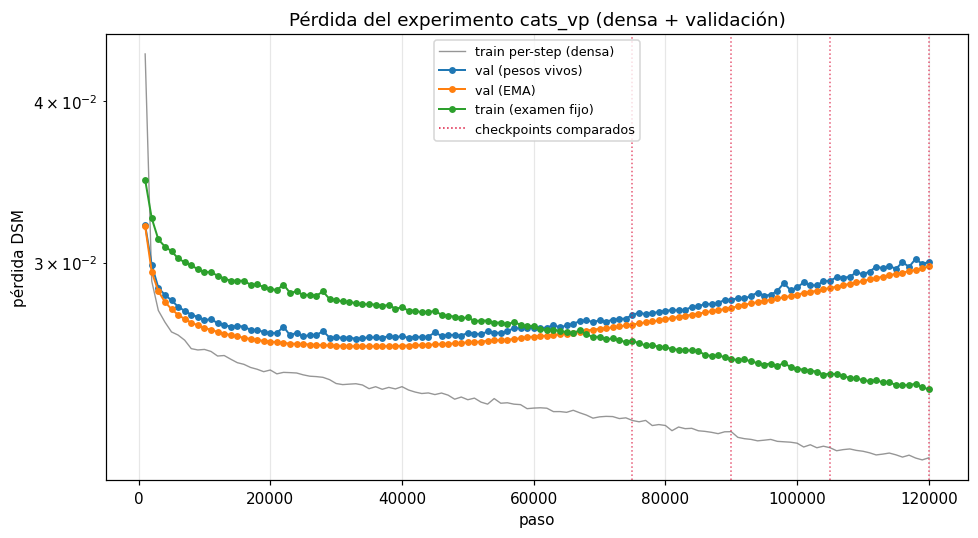

In [14]:
# --- Figura 1: pérdida del experimento (densa + validación) con los checkpoints marcados ---
pasos_ckpt = [paso for paso, _p, _m in ckpts]

fig, ax = plt.subplots(figsize=(9, 5))

if steps_ev:
    ax.plot([r["step"] for r in steps_ev], [r["loss"] for r in steps_ev],
            lw=0.9, alpha=0.75, color="0.45", label="train per-step (densa)")

series = [("val_raw", "val (pesos vivos)", "C0"),
          ("val_ema", "val (EMA)", "C1"),
          ("train_fijo", "train (examen fijo)", "C2")]
for clave, etiqueta, color in series:
    pts = [(r["step"], r[clave]) for r in vals_ev if r.get(clave) is not None]
    if not pts:
        continue
    xs, ys = zip(*pts)
    ax.plot(xs, ys, marker="o", ms=3.5, lw=1.3, color=color, label=etiqueta)

# Fallback: si no hay log, usar el val_history del checkpoint más avanzado.
if not vals_ev:
    vh = ckpts[-1][2].get("val_history") or []
    for clave, etiqueta, color in [("raw", "val (pesos vivos)", "C0"),
                                   ("ema", "val (EMA)", "C1"),
                                   ("train", "train (examen fijo)", "C2")]:
        pts = [(p["step"], p[clave]) for p in vh if p.get(clave) is not None]
        if pts:
            xs, ys = zip(*pts)
            ax.plot(xs, ys, marker="o", ms=3.5, lw=1.3, color=color,
                    label=f"{etiqueta} (meta)")

for paso in pasos_ckpt:
    ax.axvline(paso, color="crimson", ls=":", lw=1.0, alpha=0.7)
ax.plot([], [], color="crimson", ls=":", lw=1.0, label="checkpoints comparados")

todas = [r["loss"] for r in steps_ev] + [
    r[c] for r in vals_ev for c, _e, _col in series if r.get(c) is not None
]
if todas and min(todas) > 0:
    ax.set_yscale("log")
ax.set_xlabel("paso")
ax.set_ylabel("pérdida DSM")
ax.set_title("Pérdida del experimento cats_vp (densa + validación)")
ax.grid(alpha=0.3)
ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

## 3. raw vs EMA

`val_raw` usa los **pesos vivos** (el último paso de Adam) y `val_ema` la **sombra EMA**. Comparar las
dos dice si el promediado está ayudando: con `ema_decay=0.999` la ventana efectiva es de ~1000 pasos,
así que al principio el EMA va **por encima** (arrastra pesos viejos, peores) y a medida que la
corrida se estabiliza tiende a igualar o mejorar la curva cruda.

El panel inferior muestra la diferencia $\text{val}_\text{EMA} - \text{val}_\text{raw}$: **negativo =
el EMA es mejor**.

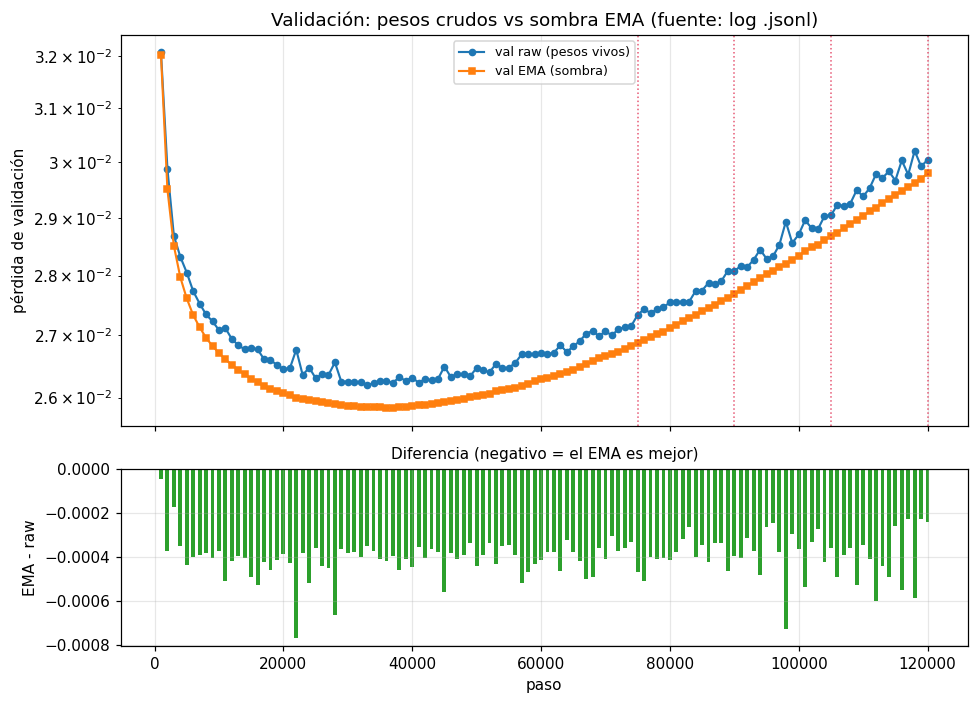

puntos medidos: 120 | EMA mejor en 120 | raw mejor en 0
último punto (paso 120,000): raw=0.030039  ema=0.029797  delta=-0.000242


In [15]:
# --- Figura 2: raw vs EMA (y su diferencia) ---
if vals_ev:
    pares = [(r["step"], r["val_raw"], r["val_ema"]) for r in vals_ev
             if r.get("val_raw") is not None and r.get("val_ema") is not None]
    fuente = "log .jsonl"
else:
    vh = ckpts[-1][2].get("val_history") or []
    pares = [(p["step"], p["raw"], p["ema"]) for p in vh
             if p.get("raw") is not None and p.get("ema") is not None]
    fuente = "meta del checkpoint"

if not pares:
    print("No hay puntos con raw Y ema: ¿la corrida tenía 'ema_decay' y 'data.val_root'?")
else:
    xs = [p[0] for p in pares]
    raw = [p[1] for p in pares]
    ema = [p[2] for p in pares]
    delta = [e - r for r, e in zip(raw, ema)]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(9, 6.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]}
    )
    ax1.plot(xs, raw, marker="o", ms=4, lw=1.4, color="C0", label="val raw (pesos vivos)")
    ax1.plot(xs, ema, marker="s", ms=4, lw=1.4, color="C1", label="val EMA (sombra)")
    for paso in pasos_ckpt:
        ax1.axvline(paso, color="crimson", ls=":", lw=1.0, alpha=0.7)
    if min(raw + ema) > 0:
        ax1.set_yscale("log")
    ax1.set_ylabel("pérdida de validación")
    ax1.set_title(f"Validación: pesos crudos vs sombra EMA (fuente: {fuente})")
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize="small")

    colores = ["C2" if d < 0 else "C3" for d in delta]
    ax2.bar(xs, delta, width=max(1.0, 0.6 * (xs[1] - xs[0]) if len(xs) > 1 else 1.0), color=colores)
    ax2.axhline(0.0, color="0.3", lw=1.0)
    ax2.set_xlabel("paso")
    ax2.set_ylabel("EMA - raw")
    ax2.grid(alpha=0.3)
    ax2.set_title("Diferencia (negativo = el EMA es mejor)", fontsize=10)
    fig.tight_layout()
    plt.show()

    mejor = sum(1 for d in delta if d < 0)
    print(f"puntos medidos: {len(delta)} | EMA mejor en {mejor} | raw mejor en {len(delta) - mejor}")
    print(f"último punto (paso {xs[-1]:,}): raw={raw[-1]:.6f}  ema={ema[-1]:.6f}  "
          f"delta={delta[-1]:+.6f}")

## 4. Generación comparada: los 4 checkpoints, mismo ruido

Cada checkpoint genera con el **mismo sampler, el mismo presupuesto de NFE y la misma semilla**,
así el $x_T$ inicial es idéntico y la única variable es **cuánto entrenó** el modelo. Las filas van de
menos a más entrenado.

El presupuesto se expresa en **NFE** (evaluaciones de la U-Net) y no en pasos, igual que en el notebook 07: acá las cuatro
filas comparten sampler, así que la comparación ya era justa, pero decirlo en NFE hace que el número sea comparable entre
notebooks y que cambiar de sampler no altere el cómputo en silencio.

> Costo: son 4 corridas de sampleo completas. Con la U-Net de 37M a 64×64 conviene GPU; bajá
> `N_STEPS_GEN` o `N_SAMPLES` si tarda mucho.

generando desde cats_vp_step75000.pt (paso 75,000)…
   shape=(4, 3, 64, 64) rango=(-1.04, 1.06) finito=True
generando desde cats_vp_step90000.pt (paso 90,000)…
   shape=(4, 3, 64, 64) rango=(-1.03, 1.04) finito=True
generando desde cats_vp_step105000.pt (paso 105,000)…
   shape=(4, 3, 64, 64) rango=(-1.03, 1.04) finito=True
generando desde cats_vp.pt (paso 120,000)…
   shape=(4, 3, 64, 64) rango=(-1.03, 1.04) finito=True


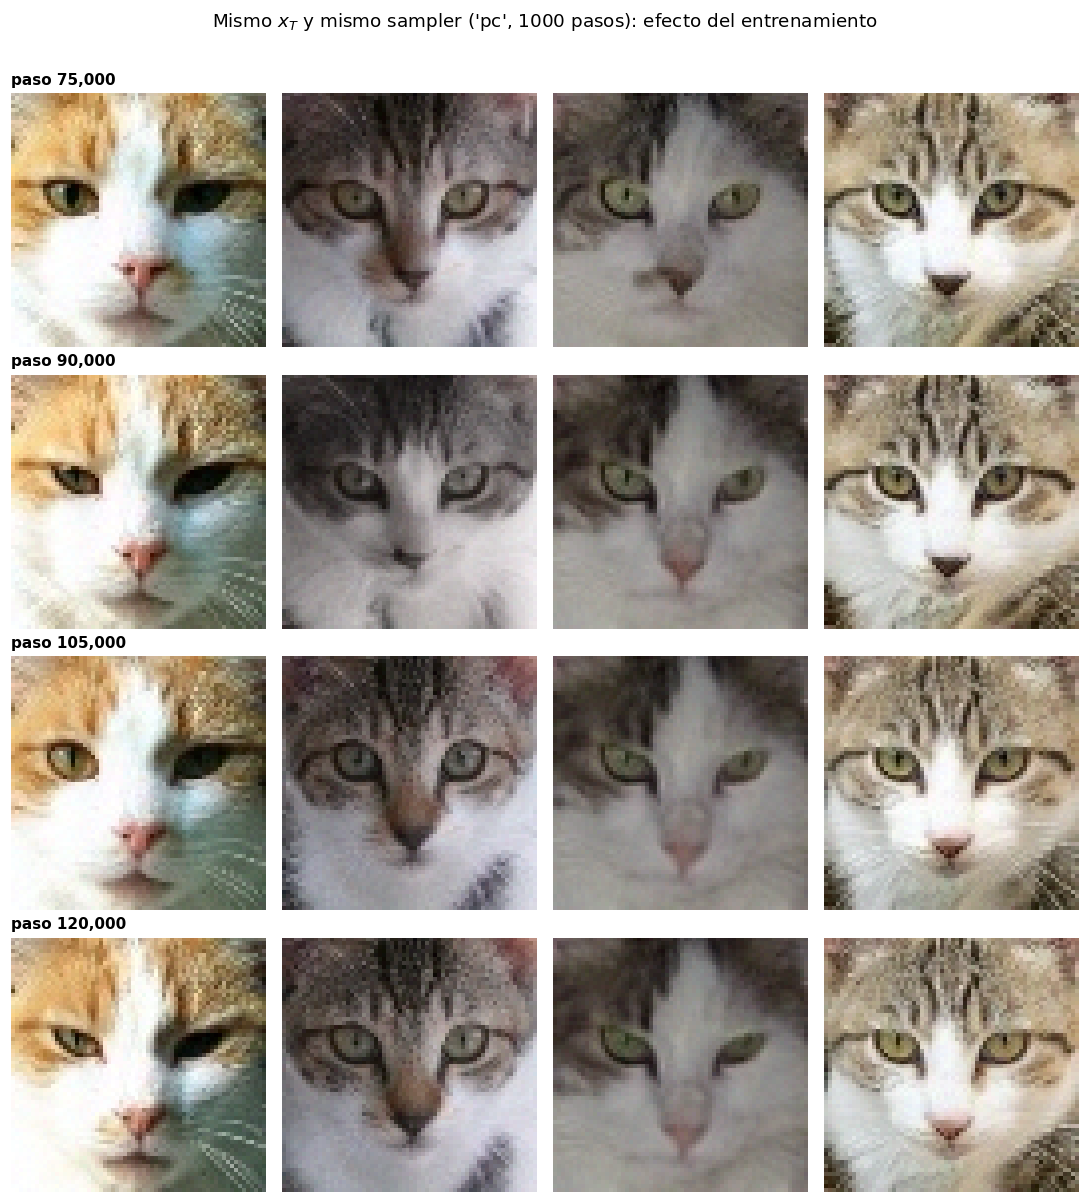

In [17]:
# --- Generación con los 4 checkpoints (mismo sampler + misma semilla) ---
SAMPLER = "pc"       # predictor-corrector: el más estable (ver notebooks 06/07)
N_SAMPLES = 4
# Acá las 4 filas usan el MISMO sampler, así que la comparación ya era justa. El
# presupuesto se expresa igual en NFE: así el número es comparable contra los notebooks
# 06/07, y si algún día se cambia `SAMPLER` los pasos se reajustan solos en vez de
# cambiar el cómputo por debajo sin avisar.
NFE_GEN = 2000
N_STEPS_GEN = pasos_para(SAMPLER, NFE_GEN)
print(f"sampler '{SAMPLER}': {N_STEPS_GEN} pasos x {NFE_POR_PASO[SAMPLER]} = {NFE_GEN} NFE")

muestras = {}
for paso, p, _meta in ckpts:
    print(f"generando desde {p.name} (paso {paso:,})…", flush=True)
    x0 = generate_from_checkpoint(
        p, sampler_name=SAMPLER, n_samples=N_SAMPLES, n_steps=N_STEPS_GEN,
        seed=SEED, device=DEVICE, **kwargs_para(SAMPLER),
    ).cpu()
    muestras[paso] = x0
    print(f"   shape={tuple(x0.shape)} rango=({float(x0.min()):.2f}, {float(x0.max()):.2f}) "
          f"finito={bool(torch.isfinite(x0).all())}")

fig, axes = plt.subplots(
    len(ckpts), N_SAMPLES, figsize=(2.5 * N_SAMPLES, 2.7 * len(ckpts)), squeeze=False
)
for fila, (paso, p, _m) in enumerate(ckpts):
    arr = denorm(muestras[paso])
    for col in range(N_SAMPLES):
        ax = axes[fila][col]
        ax.imshow(arr[col])
        ax.axis("off")
        if col == 0:
            ax.set_title(f"paso {paso:,}", fontsize=10, fontweight="bold", loc="left")
fig.suptitle(
    f"Mismo $x_T$ y mismo sampler ('{SAMPLER}', {N_STEPS_GEN} pasos = {NFE_GEN} NFE): "
    f"efecto del entrenamiento",
    fontsize=12, y=1.01,
)
fig.tight_layout()
plt.show()

## Cierre

- **Los 4 checkpoints** son snapshots de una misma corrida (`…_stepNNNNN.pt` + el final), descubiertos
  automáticamente y ordenados por paso; los sidecars `.resume.pt` se excluyen a propósito.
- **La curva del experimento** sale del `.jsonl`: densa de entrenamiento + las tres series de
  validación, con los pasos de los checkpoints marcados (y el `val_history` del meta como respaldo si
  el log no está a mano).
- **raw vs EMA** compara los pesos vivos contra la sombra EMA en el mismo examen fijo; el panel de
  diferencia dice de un vistazo cuándo el promediado ayuda.
- **La grilla de generación** aísla el efecto del entrenamiento: mismo ruido inicial y mismo sampler
  en las 4 filas.

Para el estudio del **Eje 2** (comparar los 4 samplers sobre *un* checkpoint) el notebook es el `07`.